In [1]:
import joblib
import numpy as np
import os
import sys
sys.path.append(os.path.abspath(".."))


import matplotlib.pyplot as plt
import seaborn as sb


from sklearn.metrics import fbeta_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc


from scipy import stats


from MLstatkit import Delong_test


from src.load_tests import get_model_type
from src.load_tests import load_test

## Nacitanie modelov

In [2]:
model_lists: list[str] = ["rf6_en_1", "rf6i_en_1", "rf6s_en_1"]
base_path: str = "../results"
tests = {}

for model in model_lists:
    model_type = get_model_type(model)
    path = os.path.join(base_path, model_type, model)
    print(path)

    tests[model] = load_test(path)
    

../results/rf/rf6_en_1
../results/rf/rf6i_en_1
../results/rf/rf6s_en_1


## Mohol by som sem pridat funkciu, na vykreslovanie gafov
- aspon pre tych, ktore dokazem vykreslit jednou funkciu

## ROC & RP Curve

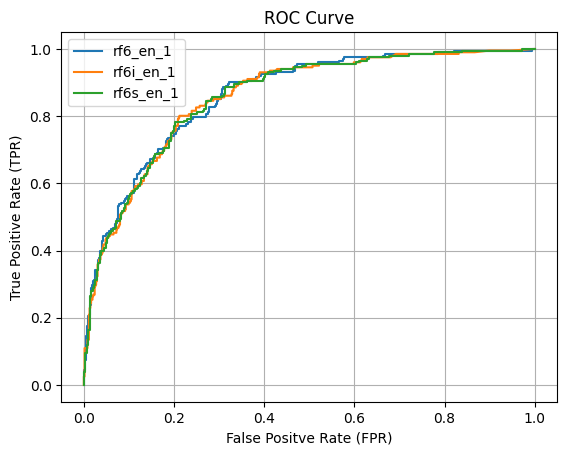

rf6_en_1 0.86186
rf6i_en_1 0.85813
rf6s_en_1 0.85857


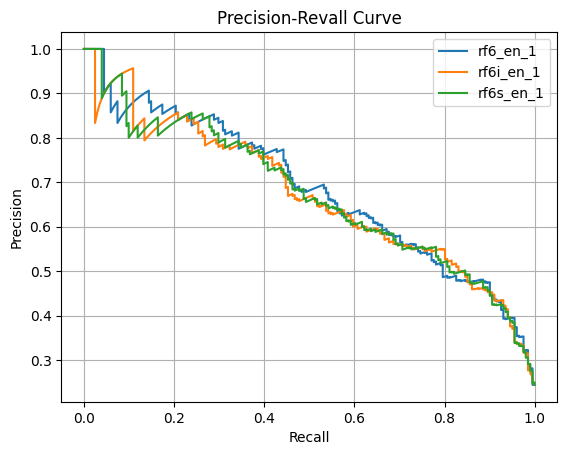

In [5]:
roc_results = {}
pr_results = {}


for test, data in tests.items():
    y_true = data["y_true"]
    y_proba = data["y_proba"]
    #print(test)
    #print(y_true.shape, y_proba.shape)

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    roc_results[test] = (fpr, tpr)
    pr_results[test] = (precision, recall)

for test, (fpr, tpr) in roc_results.items():
    plt.plot(fpr, tpr, label=test)
plt.xlabel("False Positve Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

for test, (fpr, tpr) in roc_results.items():
    print(test, round(auc(fpr, tpr), 5))

for test, (precision, recall) in pr_results.items():
    plt.plot(recall, precision, label=test)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Revall Curve")
plt.legend()
plt.grid()
plt.show()



## DeLong's Test

- H0: The difference between AUCs of two models is no significant difference
- H1: The difference between AUCs is a significant difference
- p_value < 0.05 = rozdiel je statsticky vyznamny / rozdiel nie je statisticky vyznamny

In [ ]:
# ["rf6_en_1", "rf6i_en_1", "rf6s_en_1"]

p_value_lr_knn = Delong_test(
    y_true,
    tests["rf6_en_1"]["y_proba"],
    tests["rf6i_en_1"]["y_proba"]
)

p_value_lr_rf = Delong_test(
    y_true,
    tests["rf6_en_1"]["y_proba"],
    tests["rf6s_en_1"]["y_proba"]
)

p_value_rf_knn = Delong_test(
    y_true,
    tests["rf6i_en_1"]["y_proba"],
    tests["rf6s_en_1"]["y_proba"]
)



print("p value (lr, knn):", round(p_value_lr_knn[1], 5))
print("p value (lr, rf):", round(p_value_lr_rf[1], 5))
print("p value (rf, knn):", round(p_value_rf_knn[1], 5))

p value (lr, knn): 0.18204
p value (lr, rf): 0.16482
p value (rf, knn): 0.80161
